In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка отображения, чтобы видеть все столбцы
pd.set_option('display.max_columns', None)


In [3]:
print("выгрузка и первичный анализ")

#Загружаем данные
df = pd.read_csv('C:/Users/Redmi/Desktop/practise2026/data/raw/ai_student_impact_dataset (1).csv') 

print(f"\n Данные загружены: {df.shape[0]} строк, {df.shape[1]} столбцов")

выгрузка и первичный анализ

 Данные загружены: 50000 строк, 16 столбцов


In [4]:
# Информация о данных
print("\n--- Информация о столбцах ---")
print(df.info())

# Первые строки
print("\n--- Первые 5 строк ---")
print(df.head())

# Статистика
print("\n--- Статистика числовых признаков ---")
print(df.describe())

# Проверка пропусков
print("\n--- Пропущенные значения ---")
print(df.isnull().sum())


--- Информация о столбцах ---
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semest


--- Распределение Burnout_Risk_Level ---
Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64


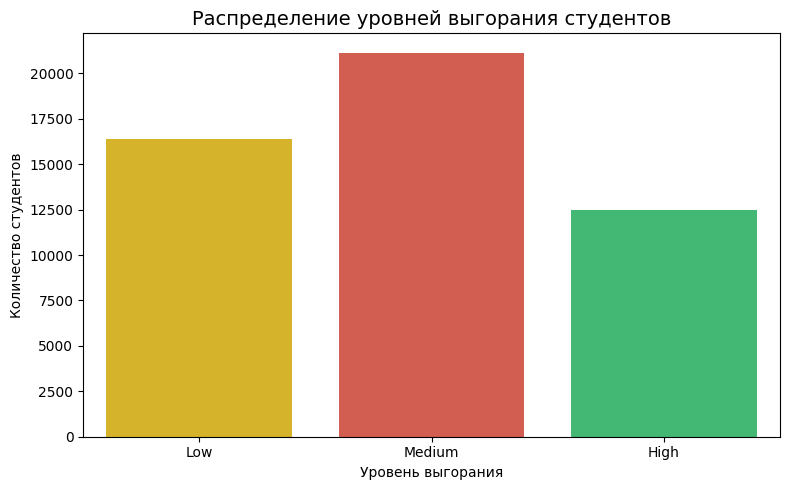

In [5]:
# Распределение целевой переменной
print("\n--- Распределение Burnout_Risk_Level ---")
print(df['Burnout_Risk_Level'].value_counts())

# Базовая визуализация
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df, 
    x='Burnout_Risk_Level', 
    order=['Low', 'Medium', 'High'],
    hue='Burnout_Risk_Level', 
    palette=['#2ecc71', '#f1c40f', '#e74c3c'],
    legend=False  
)
plt.title('Распределение уровней выгорания студентов', fontsize=14)
plt.xlabel('Уровень выгорания')
plt.ylabel('Количество студентов')
plt.tight_layout()
plt.savefig('C:/Users/Redmi/Desktop/practise2026/data/result/burnout_distribution.png', dpi=300)
plt.show()
#testcommit


In [7]:
from sklearn.preprocessing import LabelEncoder
print("ОТБОР ПРИЗНАКОВ И КОДИРОВАНИЕ")

#непр признаки
features = [
    'Weekly_GenAI_Hours',
    'Traditional_Study_Hours',
    'Perceived_AI_Dependency',
    'Anxiety_Level_During_Exams',
    'Tool_Diversity'
]

X = df[features].copy()
y = df['Burnout_Risk_Level'].copy()

print(f"Отобрано {len(features)} непрерывных признаков")
print(f"   Признаки: {', '.join(features)}")

# Кодируем
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)

print(f"\n Целевая переменная закодирована")
print(f"   Соответствие: {dict(zip(le_y.classes_, le_y.transform(le_y.classes_)))}")

# Проверка
print("\n--- Первые 5 строк ---")
print(X.head())

ОТБОР ПРИЗНАКОВ И КОДИРОВАНИЕ
Отобрано 5 непрерывных признаков
   Признаки: Weekly_GenAI_Hours, Traditional_Study_Hours, Perceived_AI_Dependency, Anxiety_Level_During_Exams, Tool_Diversity

 Целевая переменная закодирована
   Соответствие: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

--- Первые 5 строк ---
   Weekly_GenAI_Hours  Traditional_Study_Hours  Perceived_AI_Dependency  \
0               23.31                     8.13                        5   
1                1.12                    16.65                        3   
2               21.26                    10.35                        5   
3                1.82                    15.23                        2   
4                9.29                    12.55                        4   

   Anxiety_Level_During_Exams  Tool_Diversity  
0                           6               1  
1                           9               5  
2                           9               2  
3                           


ПРОВЕРКА УСЛОВИЙ ПРИМЕНИМОСТИ GAUSSIAN NAIVE BAYES

ПРОВЕРКА НА НОРМАЛЬНОСТЬ


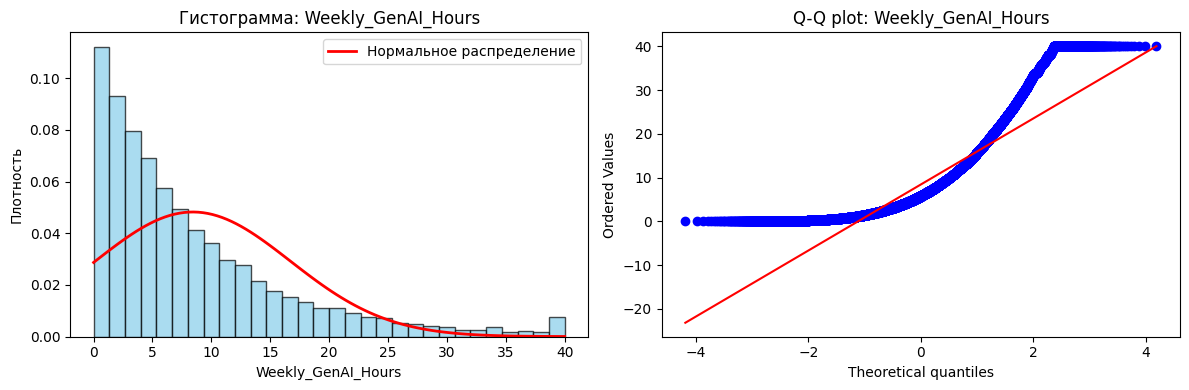

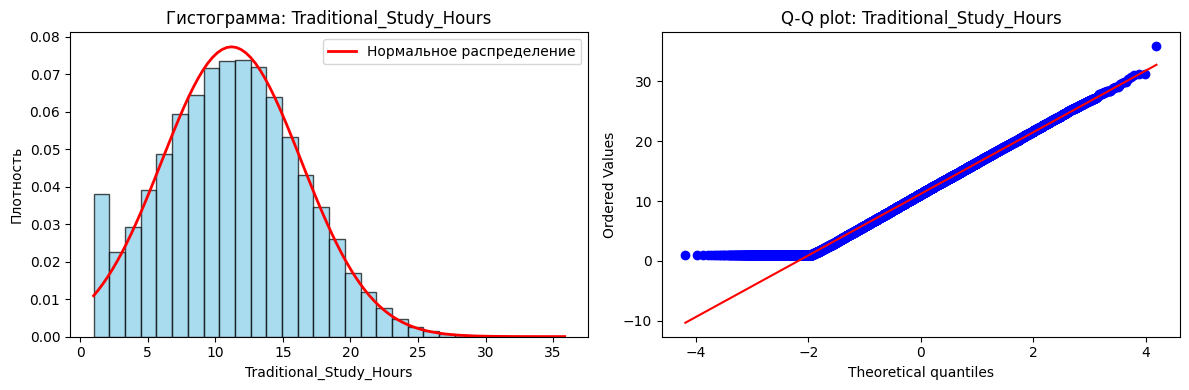

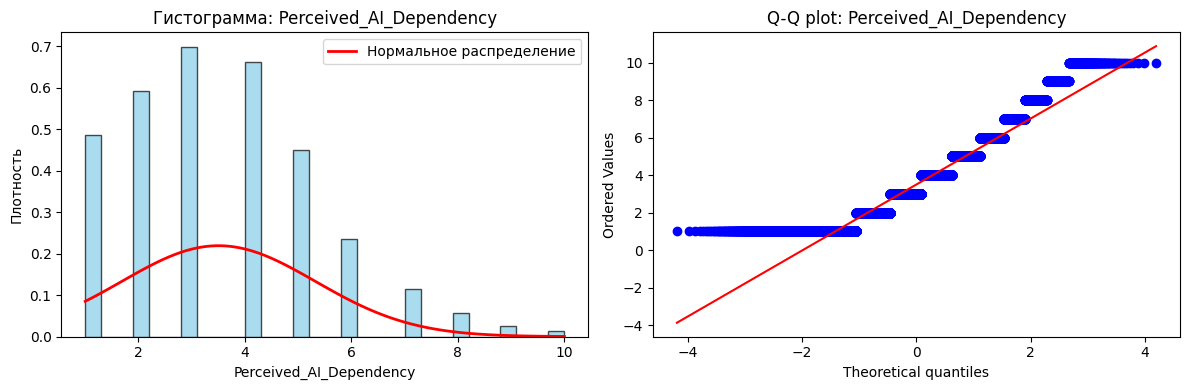

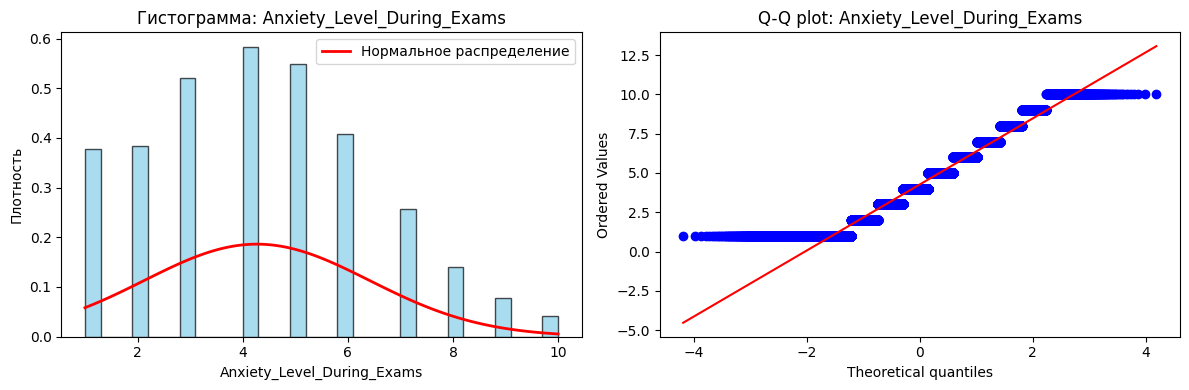

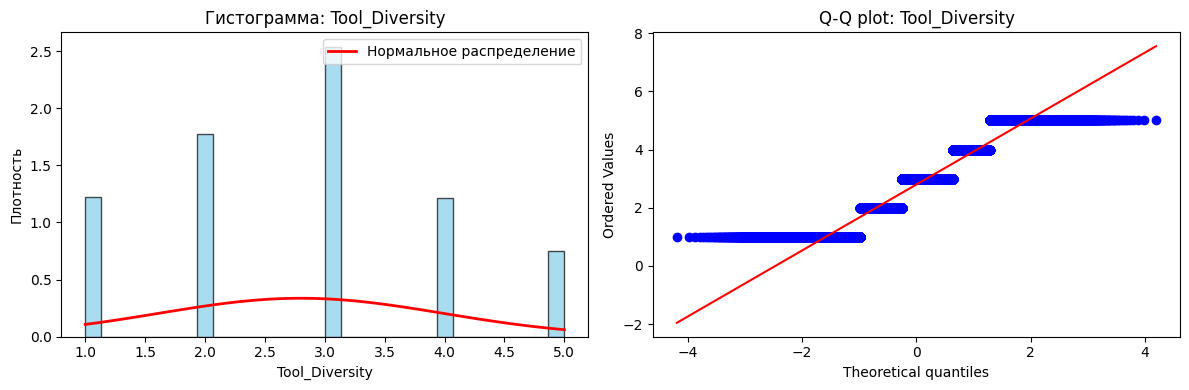


ПРОВЕРКА НА НЕЗАВИСИМОСТЬ


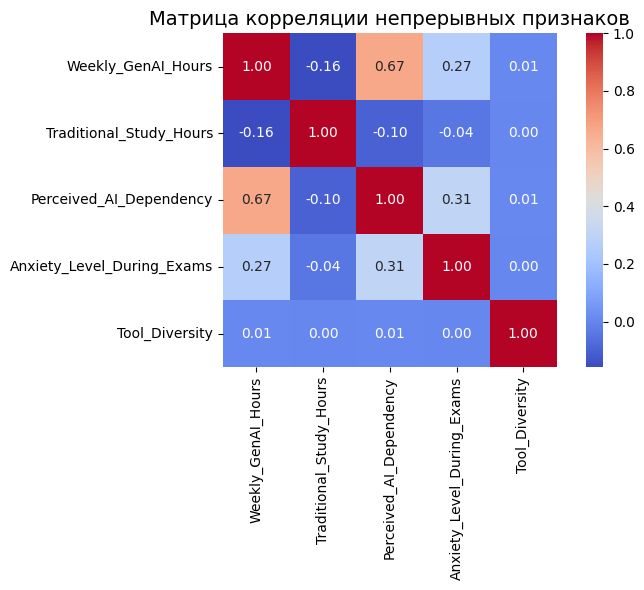


Самые сильные корреляции (|r| > 0.3):
  Weekly_GenAI_Hours — Perceived_AI_Dependency: 0.67
  Perceived_AI_Dependency — Anxiety_Level_During_Exams: 0.31


In [10]:
#проверки
import scipy.stats as stats
import os

print("ПРОВЕРКА УСЛОВИЙ")


print("\nПРОВЕРКА НА НОРМАЛЬНОСТЬ")

for col in X.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Гистограмма с кривой нормального распределения
    axes[0].hist(X[col], bins=30, density=True, edgecolor='black', alpha=0.7, color='skyblue')
    mu, std = X[col].mean(), X[col].std()
    x = np.linspace(X[col].min(), X[col].max(), 100)
    axes[0].plot(x, stats.norm.pdf(x, mu, std), 'r-', linewidth=2, label='Нормальное распределение')
    axes[0].set_title(f'Гистограмма: {col}', fontsize=12)
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Плотность')
    axes[0].legend()

    stats.probplot(X[col], dist="norm", plot=axes[1])
    axes[1].set_title(f'Q-Q plot: {col}', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(f'C:/Users/Redmi/Desktop/practise2026/data/result/normality_{col}.png', dpi=300)
    plt.show()

print("\nПРОВЕРКА НА НЕЗАВИСИМОСТЬ")

corr_matrix = X.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Матрица корреляции непрерывных признаков', fontsize=14)
plt.tight_layout()
plt.savefig(f'C:/Users/Redmi/Desktop/practise2026/data/result/correlation_matrix.png', dpi=300)
plt.show()

print("\nСамые сильные корреляции (|r| > 0.3):")
found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.3:
            print(f"  {corr_matrix.columns[i]} — {corr_matrix.columns[j]}: {corr_val:.2f}")
            found = True
if not found:
    print("  Сильных корреляций не обнаружено (все |r| <= 0.3)")


In [11]:
from sklearn.preprocessing import LabelEncoder
print("ОТБОР ПРИЗНАКОВ И КОДИРОВАНИЕ")

#непр признаки
features = [
    'Weekly_GenAI_Hours',
    'Traditional_Study_Hours',
    'Anxiety_Level_During_Exams',
    'Tool_Diversity'
]

X = df[features].copy()
y = df['Burnout_Risk_Level'].copy()

print(f"Отобрано {len(features)} непрерывных признаков")
print(f"   Признаки: {', '.join(features)}")

# Кодируем
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)

print(f"\n Целевая переменная закодирована")
print(f"   Соответствие: {dict(zip(le_y.classes_, le_y.transform(le_y.classes_)))}")

# Проверка
print("\n--- Первые 5 строк ---")
print(X.head())

ОТБОР ПРИЗНАКОВ И КОДИРОВАНИЕ
Отобрано 4 непрерывных признаков
   Признаки: Weekly_GenAI_Hours, Traditional_Study_Hours, Anxiety_Level_During_Exams, Tool_Diversity

 Целевая переменная закодирована
   Соответствие: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

--- Первые 5 строк ---
   Weekly_GenAI_Hours  Traditional_Study_Hours  Anxiety_Level_During_Exams  \
0               23.31                     8.13                           6   
1                1.12                    16.65                           9   
2               21.26                    10.35                           9   
3                1.82                    15.23                           2   
4                9.29                    12.55                           4   

   Tool_Diversity  
0               1  
1               5  
2               2  
3               4  
4               4  



ПРОВЕРКА УСЛОВИЙ ПРИМЕНИМОСТИ GAUSSIAN NAIVE BAYES

ПРОВЕРКА НА НОРМАЛЬНОСТЬ


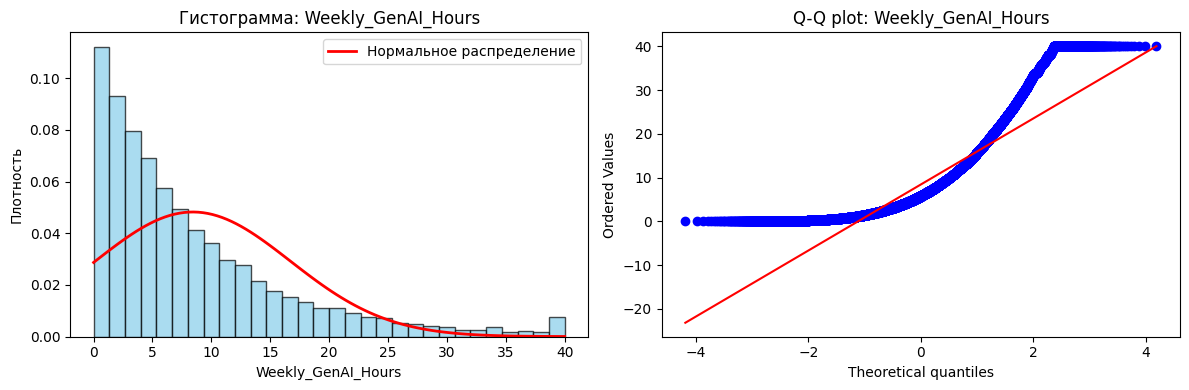

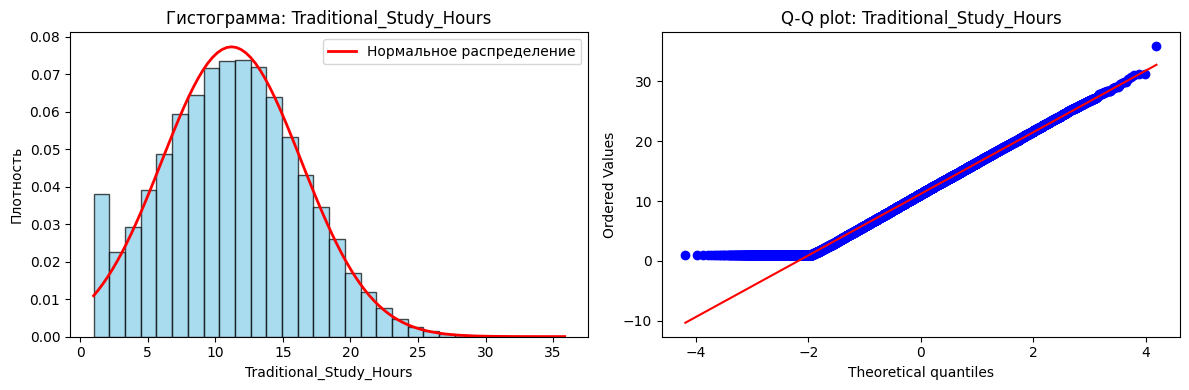

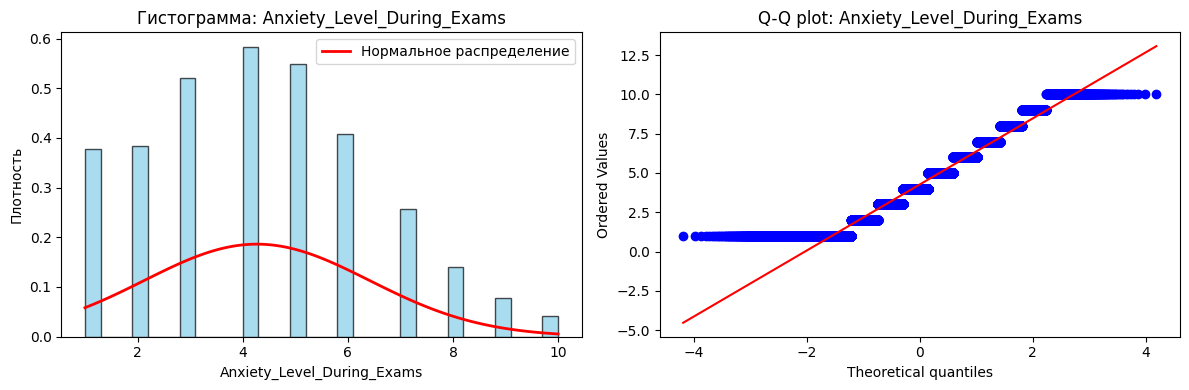

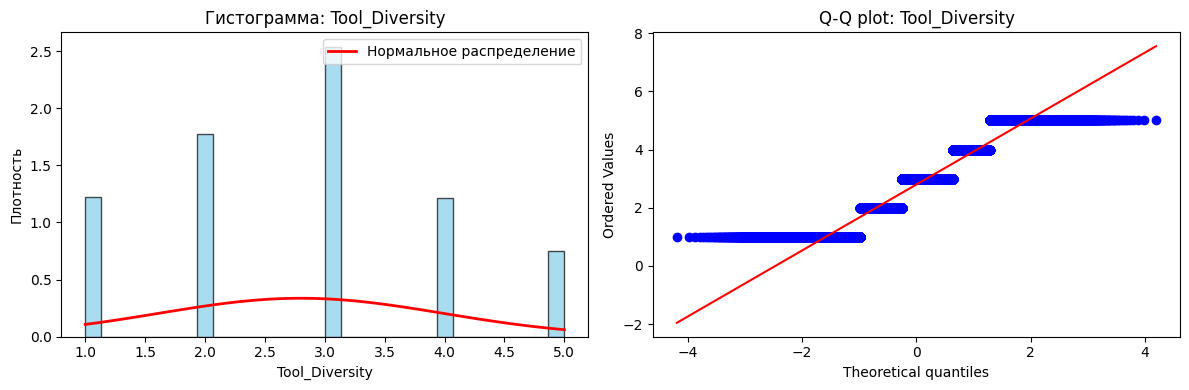


ПРОВЕРКА НА НЕЗАВИСИМОСТЬ


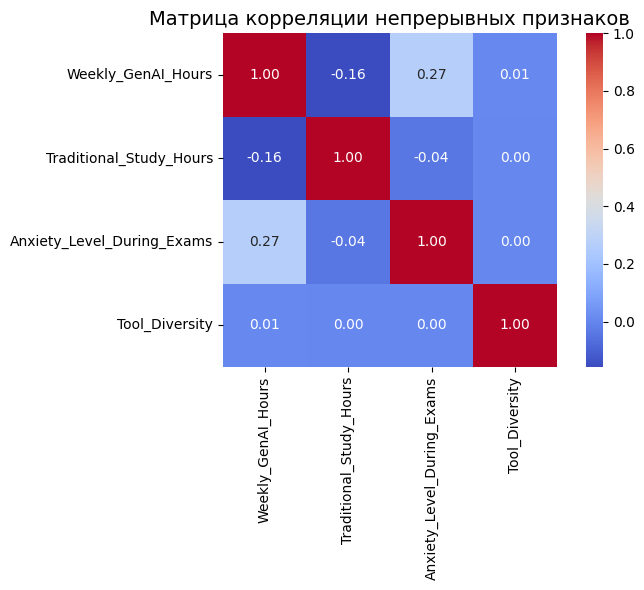


Самые сильные корреляции (|r| > 0.3):
  Сильных корреляций не обнаружено (все |r| <= 0.3)


In [12]:
#проверки
import scipy.stats as stats
import os

print("ПРОВЕРКА УСЛОВИЙ")


print("\nПРОВЕРКА НА НОРМАЛЬНОСТЬ")

for col in X.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Гистограмма с кривой нормального распределения
    axes[0].hist(X[col], bins=30, density=True, edgecolor='black', alpha=0.7, color='skyblue')
    mu, std = X[col].mean(), X[col].std()
    x = np.linspace(X[col].min(), X[col].max(), 100)
    axes[0].plot(x, stats.norm.pdf(x, mu, std), 'r-', linewidth=2, label='Нормальное распределение')
    axes[0].set_title(f'Гистограмма: {col}', fontsize=12)
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Плотность')
    axes[0].legend()

    stats.probplot(X[col], dist="norm", plot=axes[1])
    axes[1].set_title(f'Q-Q plot: {col}', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(f'C:/Users/Redmi/Desktop/practise2026/data/result/normality_{col}.png', dpi=300)
    plt.show()

print("\nПРОВЕРКА НА НЕЗАВИСИМОСТЬ")

corr_matrix = X.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Матрица корреляции непрерывных признаков', fontsize=14)
plt.tight_layout()
plt.savefig(f'C:/Users/Redmi/Desktop/practise2026/data/result/correlation_matrix.png', dpi=300)
plt.show()

print("\nСамые сильные корреляции (|r| > 0.3):")
found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.3:
            print(f"  {corr_matrix.columns[i]} — {corr_matrix.columns[j]}: {corr_val:.2f}")
            found = True
if not found:
    print("  Сильных корреляций не обнаружено (все |r| <= 0.3)")
